In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
# import dataset
df=pd.read_csv("property_price_data.csv")
df.head()

,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleCondition,SalePrice
0,PRO504,20,RL,100.0,15537,Pave,NaN,IR1,Lvl,AllPub,...,0,161,0,NaN,GdWo,NaN,0,2010,Normal,288330
1,PRO102,60,RL,77.0,9534,Pave,NaN,Reg,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2010,Normal,183164
2,PRO609,70,RL,NaN,12781,Pave,NaN,Reg,HLS,AllPub,...,0,0,0,NaN,NaN,NaN,0,2007,Alloca,362145
3,PRO1090,120,FV,37.0,3728,Pave,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2006,Normal,196079
4,PRO820,120,RL,44.0,6606,Pave,NaN,IR1,Lvl,AllPub,...,0,0,0,NaN,NaN,NaN,0,2010,Partial,228515


In [5]:
len(df.columns)

69

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   Alley          56 non-null     object 
 7   LotShape       970 non-null    object 
 8   LandContour    970 non-null    object 
 9   Utilities      970 non-null    object 
 10  LotConfig      970 non-null    object 
 11  LandSlope      970 non-null    object 
 12  Neighborhood   970 non-null    object 
 13  Condition1     970 non-null    object 
 14  Condition2     970 non-null    object 
 15  BldgType       970 non-null    object 
 16  PropStyle      970 non-null    object 
 17  OverallQual    970 non-null    int64  
 18  OverallCon

In [9]:
df.isnull().sum()

Prop_Id            0
MSSubClass         0
MSZoning           0
LotFrontage      181
LotArea            0
                ... 
MiscFeature      941
MiscVal            0
YrSold             0
SaleCondition      0
SalePrice          0
Length: 69, dtype: int64

In [11]:
## Getting All Different Types OF Features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))


Num of Numerical Features : 29
Num of Categorical Features : 40


In [13]:
num_features

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'YrSold',
 'SalePrice']

In [15]:
cat_features

['Prop_Id',
 'MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'PropStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleCondition']

In [17]:
# MiscFeature this feature has  null value we can remove this feature
df.drop('MiscFeature', axis=1, inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 68 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   Alley          56 non-null     object 
 7   LotShape       970 non-null    object 
 8   LandContour    970 non-null    object 
 9   Utilities      970 non-null    object 
 10  LotConfig      970 non-null    object 
 11  LandSlope      970 non-null    object 
 12  Neighborhood   970 non-null    object 
 13  Condition1     970 non-null    object 
 14  Condition2     970 non-null    object 
 15  BldgType       970 non-null    object 
 16  PropStyle      970 non-null    object 
 17  OverallQual    970 non-null    int64  
 18  OverallCon

In [21]:
df['Fence'].isnull().sum()
df['PoolQC'].isnull().sum()

963

In [23]:
# Fence fetures have also a lot of null value we can remove this column also
df.drop('Fence',axis=1,inplace=True)
# PoolQC fetures need to drop also
df.drop('PoolQC',axis=1,inplace=True)

In [25]:
# Alley   feture has 56 non-null and a lot of null valu we need to remove this feture also
df.drop('Alley',axis=1,inplace=True)

In [27]:
len(df.columns)

65

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 65 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   LotShape       970 non-null    object 
 7   LandContour    970 non-null    object 
 8   Utilities      970 non-null    object 
 9   LotConfig      970 non-null    object 
 10  LandSlope      970 non-null    object 
 11  Neighborhood   970 non-null    object 
 12  Condition1     970 non-null    object 
 13  Condition2     970 non-null    object 
 14  BldgType       970 non-null    object 
 15  PropStyle      970 non-null    object 
 16  OverallQual    970 non-null    int64  
 17  OverallCond    970 non-null    int64  
 18  YearBuilt 

In [31]:
# fill missing value in GarageCond
df['GarageCond'].unique()
df.fillna(df.GarageCond.mode()[0], inplace=True)

In [33]:
# filling missing values in GarageQual
df['GarageQual'].unique()
df.fillna(df.GarageQual.mode()[0],inplace=True)

In [35]:
# filling missing values in GarageFinish   918 non-null    object 
df.fillna(df.GarageFinish.mode()[0],inplace=True)

In [37]:
# filling missing values in GarageYrBlt    918 non-null    float64
df.fillna(df.GarageYrBlt.mode(),inplace=True)

In [39]:
# filling missing values GarageType     918 non-null    object
df.fillna(df.GarageType.mode()[0],inplace=True)

In [41]:
# filling missing values FireplaceQu    533 non-null    object
df.fillna(df.FireplaceQu.mode()[0],inplace=True)

In [43]:
# filling missing values in BsmtExposure   946 non-null    object
df.fillna(df.BsmtExposure.mode()[0],inplace=True)

In [45]:
# filling missing values BsmtCond       947 non-null    object 
df.fillna(df.BsmtCond.mode()[0],inplace=True)

In [47]:
# filling missing value in BsmtQual       947 non-null    object 
df.fillna(df.BsmtQual.mode()[0],inplace=True)

In [49]:
#  filling missing values LotFrontage    789 non-null    float64
df.fillna(df.LotFrontage.mode()[0],inplace=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 65 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prop_Id        970 non-null    object
 1   MSSubClass     970 non-null    int64 
 2   MSZoning       970 non-null    object
 3   LotFrontage    970 non-null    object
 4   LotArea        970 non-null    int64 
 5   Street         970 non-null    object
 6   LotShape       970 non-null    object
 7   LandContour    970 non-null    object
 8   Utilities      970 non-null    object
 9   LotConfig      970 non-null    object
 10  LandSlope      970 non-null    object
 11  Neighborhood   970 non-null    object
 12  Condition1     970 non-null    object
 13  Condition2     970 non-null    object
 14  BldgType       970 non-null    object
 15  PropStyle      970 non-null    object
 16  OverallQual    970 non-null    int64 
 17  OverallCond    970 non-null    int64 
 18  YearBuilt      970 non-null   

In [53]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
num_features

['MSSubClass',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'YrSold',
 'SalePrice']

In [55]:
cols = [
    'MSSubClass','LotArea','OverallQual','OverallCond','YearBuilt',
    'YearRemodAdd','TotalBsmtSF','GrLivArea','BsmtFullBath','BsmtHalfBath',
    'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd',
    'Fireplaces','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF',
    'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal',
    'YrSold','SalePrice'
]

df[cols].corr()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,BsmtHalfBath,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
MSSubClass,1.000000,-0.129950,0.019948,-0.092926,0.032440,0.025372,-0.234205,0.040557,0.022169,0.009946,...,-0.094783,0.002564,-0.023596,-0.027587,-0.053554,-0.025190,0.007670,0.000665,-0.030767,-0.096521
LotArea,-0.129950,1.000000,0.100610,-0.017653,0.007983,-0.016468,0.281836,0.266778,0.199641,-0.007624,...,0.192923,0.164839,0.085628,-0.018779,0.018335,0.042421,0.092997,0.035646,-0.011748,0.245488
OverallQual,0.019948,0.100610,1.000000,-0.081282,0.579983,0.555134,0.528084,0.593702,0.114288,-0.037157,...,0.555688,0.231906,0.290963,-0.122852,0.044534,0.078590,0.076598,-0.032880,-0.052716,0.787500
OverallCond,-0.092926,-0.017653,-0.081282,1.000000,-0.366450,0.049539,-0.142085,-0.082502,-0.069471,0.075234,...,-0.155025,0.000660,-0.031173,0.076703,0.031584,0.088458,-0.000327,0.074223,0.055189,-0.063376
YearBuilt,0.032440,0.007983,0.579983,-0.366450,1.000000,0.610412,0.365070,0.193299,0.188287,-0.014374,...,0.469488,0.226420,0.181434,-0.393934,0.035889,-0.057728,0.005432,-0.035758,-0.025153,0.511482
YearRemodAdd,0.025372,-0.016468,0.555134,0.049539,0.610412,1.000000,0.274017,0.270295,0.120652,-0.012252,...,0.366913,0.199238,0.203945,-0.216926,0.044297,-0.028948,0.007666,-0.009728,0.021036,0.486579
TotalBsmtSF,-0.234205,0.281836,0.528084,-0.142085,0.365070,0.274017,1.000000,0.491403,0.290092,0.002075,...,0.488308,0.216756,0.249388,-0.075454,0.042107,0.079662,0.143748,-0.015392,-0.014935,0.597116
GrLivArea,0.040557,0.266778,0.593702,-0.082502,0.193299,0.270295,0.491403,1.000000,0.048955,-0.028169,...,0.481953,0.250222,0.355612,-0.017562,0.018184,0.117288,0.193225,0.007143,-0.061379,0.705701
BsmtFullBath,0.022169,0.199641,0.114288,-0.069471,0.188287,0.120652,0.290092,0.048955,1.000000,-0.150989,...,0.164236,0.145795,0.068650,-0.028687,-0.010848,0.019717,0.081192,-0.031467,0.082266,0.226428
BsmtHalfBath,0.009946,-0.007624,-0.037157,0.075234,-0.014374,-0.012252,0.002075,-0.028169,-0.150989,1.000000,...,-0.032206,0.052388,-0.025123,-0.032910,0.022411,0.049782,0.022599,-0.013637,-0.025304,-0.017351


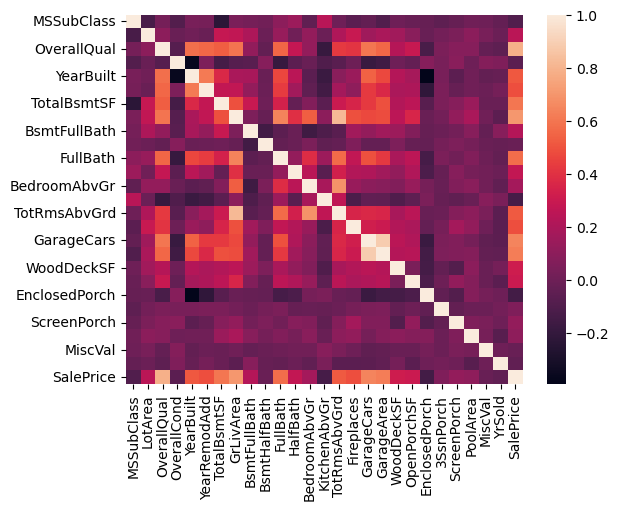

In [57]:
sns.heatmap(df[cols].corr())
plt.show()

# encoding the object data type column

In [60]:
from sklearn.preprocessing import LabelEncoder

# Identify object columns
obj_cols = df.select_dtypes(include="object").columns

# Dictionary to store encoders (optional but useful)
label_encoders = {}

# Apply Label Encoding and overwrite dataset
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("All object columns converted to Label Encoded integers")
df.head()


All object columns converted to Label Encoded integers


,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SaleCondition,SalePrice
0,610,20,3,0,15537,1,0,3,0,4,...,0,54,0,0,161,0,0,2010,4,288330
1,11,60,3,77,9534,1,3,3,0,4,...,192,46,0,0,0,0,0,2010,4,183164
2,692,70,3,100,12781,1,3,1,0,4,...,0,0,0,0,0,0,0,2007,2,362145
3,56,120,1,39,3728,1,0,3,0,4,...,0,84,0,0,0,0,0,2006,4,196079
4,844,120,3,45,6606,1,0,3,0,4,...,192,35,0,0,0,0,0,2010,5,228515


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 65 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prop_Id        970 non-null    int32
 1   MSSubClass     970 non-null    int64
 2   MSZoning       970 non-null    int32
 3   LotFrontage    970 non-null    int32
 4   LotArea        970 non-null    int64
 5   Street         970 non-null    int32
 6   LotShape       970 non-null    int32
 7   LandContour    970 non-null    int32
 8   Utilities      970 non-null    int32
 9   LotConfig      970 non-null    int32
 10  LandSlope      970 non-null    int32
 11  Neighborhood   970 non-null    int32
 12  Condition1     970 non-null    int32
 13  Condition2     970 non-null    int32
 14  BldgType       970 non-null    int32
 15  PropStyle      970 non-null    int32
 16  OverallQual    970 non-null    int64
 17  OverallCond    970 non-null    int64
 18  YearBuilt      970 non-null    int64
 19  YearRemo

In [80]:
target = "SalePrice"
X = df.drop(columns=[target])   # All features
Y = df[target]                  # Target column


In [82]:
# Create Column Transformer with 3 types of transformers
# cat_features = X.select_dtypes(include="object").columns
# num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import  LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
# le_transformer = LabelEncoder()

preprocessor = ColumnTransformer(
    [
         # ("OneHotEncoder", le_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline

# cat_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
# ])

# num_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ("cat", cat_pipeline, cat_features),
#     ("num", num_pipeline, num_features)
# ])


In [84]:
preprocessor

ColumnTransformer(transformers=[('StandardScaler', StandardScaler(),
                                 ['MSSubClass', 'LotArea', 'OverallQual',
                                  'OverallCond', 'YearBuilt', 'YearRemodAdd',
                                  'TotalBsmtSF', 'GrLivArea', 'BsmtFullBath',
                                  'BsmtHalfBath', 'FullBath', 'HalfBath',
                                  'BedroomAbvGr', 'KitchenAbvGr',
                                  'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
                                  'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
                                  'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                                  'PoolArea', 'MiscVal', 'YrSold',
                                  'SalePrice'])])

In [102]:
X.columns

Index(['Prop_Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'PropStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'SaleCondition'],
      dtype='object')

In [104]:
Y.name

'SalePrice'

In [106]:
X=preprocessor.fit_transform(X)

ValueError: A given column is not a column of the dataframe